Work description

In [11]:
'''
Наткнувся на rgb2lab, почав копати в тому напрямку, зрозумів, що це геть не те імпортив cv2. Мемно, запустив код, тепер мій тигр голубий чи синій😁
Загуглив функцію cvtColor, тигр вернувся до попереднього життя. Зрозумів, що я тупий, і витратив пів дня копаючи не в тому напрямі. Переглянув частину лекції, подивився надані посилання. 
Зрозумів, що потрібно, спробував, шось вийшло. 
Новий день, розібрався з трансформаціями. Написав код. Скачав книгу Richard Szeliski. Застряг на зворотньому афінному перетворенню, довелось питати в асистента підказки (зрозумівши кроки, 
знайшов на ютубі відео, взяв листок, олівець і розписав афінне зворотнє перетворення). Згрішив - зайшов на Вікіпедію. Відкопав свої записи, згадав властивості груп. Спробував написати доведення.
'''

'\nНаткнувся на rgb2lab, почав копати в тому напрямку, зрозумів, що це геть не те імпортив cv2. Мемно, запустив код, тепер мій тигр голубий чи синій😁\nЗагуглив функцію cvtColor, тигр вернувся до попереднього життя. Зрозумів, що я тупий, і витратив пів дня копаючи не в тому напрямі. Переглянув частину лекції, подивився надані посилання. \nЗрозумів, що потрібно, спробував, шось вийшло. \nНовий день, розібрався з трансформаціями. Написав код. Скачав книгу Richard Szeliski. Застряг на зворотньому афінному перетворенню, довелось питати в асистента підказки (зрозумівши кроки, \nзнайшов на ютубі відео, взяв листок, олівець і розписав афінне зворотнє перетворення). Згрішив - зайшов на Вікіпедію. Відкопав свої записи, згадав властивості груп. Спробував написати доведення.\n'

In [12]:
import math
import argparse
from PIL import Image

import numpy as np
import cv2
from matplotlib import pyplot as plt

In [13]:
start_image_path = "tiger-original.jpg"
image = cv2.imread(start_image_path)
height, width, _ = image.shape

print('width:  ', width)
print('height: ', height)

width:   900
height:  900


In [14]:
image = Image.open(start_image_path)

canvas_size = (width, height)
canvas_color = (255, 165, 0)
canvas = Image.new("RGB", canvas_size, canvas_color)

resizer_value = 120
tiger_image_resized = image.resize((width-resizer_value, height-resizer_value))

canvas.paste(tiger_image_resized, ((canvas_size[0] - tiger_image_resized.size[0]) // 2, 
                                   (canvas_size[1] - tiger_image_resized.size[1]) // 2))

# canvas.show()
image_path = "tiger-with-canvas.png"
canvas.save(image_path)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
factor = 39
angle = math.pi*2/100. * factor
sin_a = math.sin(angle)
cos_a = math.cos(angle)

In [15]:
def transform(transform_matrix, factor):
    dst_size = (height*3//2, width*3//2)
    image_center = np.array([width/2, height/2, 1]).T
    warped_center = np.matmul(transform_matrix, image_center)
    new_image_center = np.array([dst_size[1]/2, dst_size[0]/2, 1]).T
    translation = new_image_center[0:2] - warped_center[0:2]
    transform_matrix[0:2,2] = translation
    
    transformed_img = cv2.warpPerspective(image, transform_matrix, dst_size, borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
    
    return transformed_img

Translation

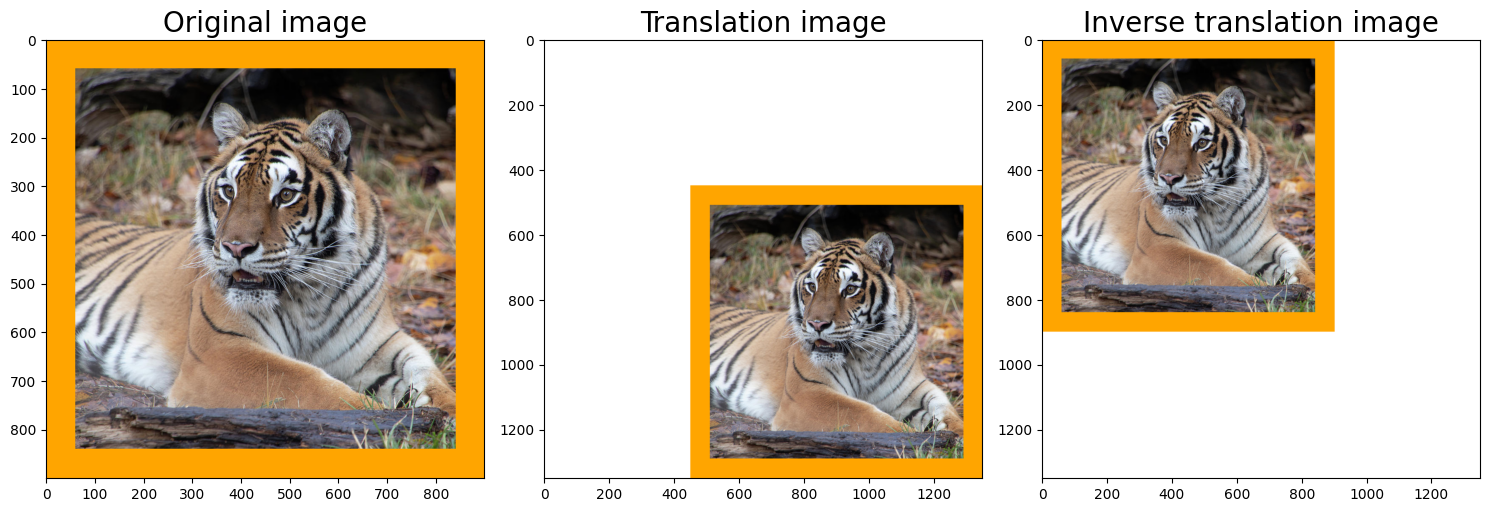

In [16]:
quarter_height, quarter_width = height / 4, width / 4

translation_matrix = np.array([
    [1, 0, -quarter_width], 
    [0, 1, -quarter_height],
    [0, 0, 1]
])

# Зворотня матриця це фактично просто зміна напрямку зміщення
inverse_translation_matrix = np.array([
    [1, 0, quarter_width],
    [0, 1, quarter_height],
    [0, 0, 1]
])

transformed_image = transform(transform_matrix=translation_matrix, factor=factor)
inverse_transformed_image = transform(transform_matrix=inverse_translation_matrix, factor=factor)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(image), plt.title('Original image', size=20)
plt.subplot(132), plt.imshow(transformed_image), plt.title('Translation image', size=20)
plt.subplot(133), plt.imshow(inverse_transformed_image), plt.title('Inverse translation image', size=20)
plt.tight_layout()
plt.show()

Euclidean

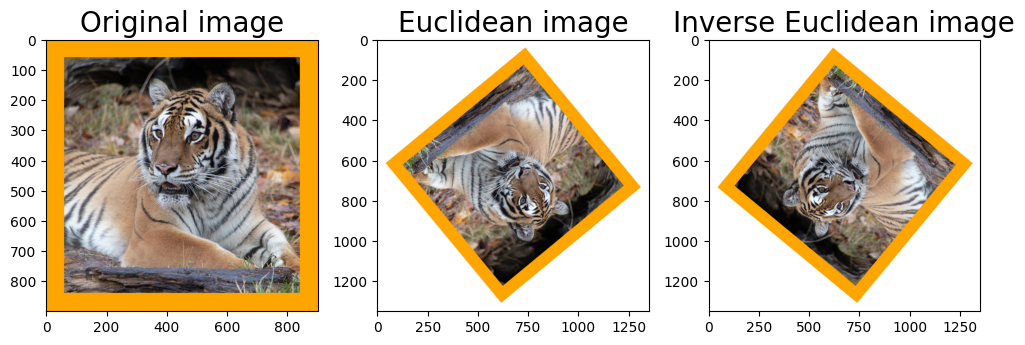

In [7]:
euclidean_matrix = np.array([
    [cos_a, -sin_a, 0],
    [sin_a, cos_a, 0],
    [0, 0, 1]
])

# Зворотня матриця це транспонування "обертання" і така сама інверсія, як зі "зсувом"
inverse_euclidean_matrix = np.array([
    [cos_a, sin_a, 0], # cos(−a)=cos(a) 
    [-sin_a, cos_a, 0], # sin(-a)=-sin(a)
    [0, 0, 1]
])

transformed_image = transform(transform_matrix=euclidean_matrix, factor=factor)
inverse_transformed_image = transform(transform_matrix=inverse_euclidean_matrix, factor=factor)

plt.figure(figsize=(10, 4))
plt.subplot(131), plt.imshow(image), plt.title('Original image', size=20)
plt.subplot(132), plt.imshow(transformed_image), plt.title('Euclidean image', size=20)
plt.subplot(133), plt.imshow(inverse_transformed_image), plt.title('Inverse Euclidean image', size=20)
plt.tight_layout()
plt.show()

Similarity

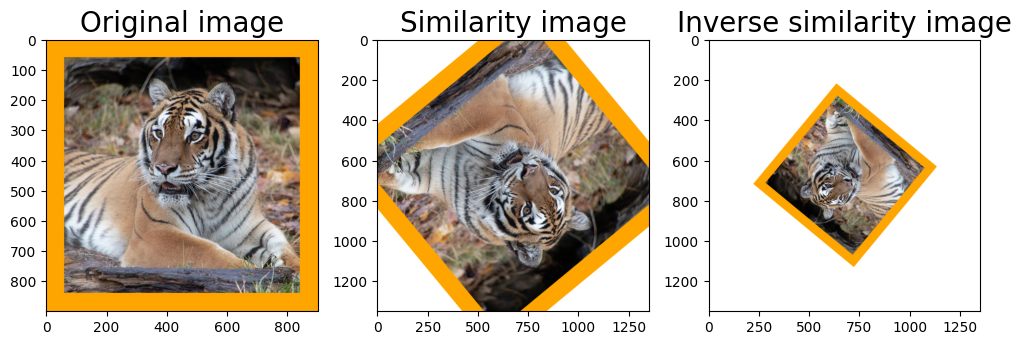

In [8]:
s = 1 + factor/100.

similarity_matrix = np.array([
    [s * cos_a, -s*sin_a, 0],
    [s*sin_a, s*cos_a, 0],
    [0, 0, 1]
])

# Зворотня матриця це та ж інверсія "обертання" і "зсуву", але ще з "масштабом"
inverse_similarity_matrix = np.array([
    [cos_a/s, sin_a/s, 0],
    [-sin_a/s, cos_a/s, 0],
    [0, 0, 1]
])

transformed_image = transform(transform_matrix=similarity_matrix, factor=factor)
inverse_transformed_image = transform(transform_matrix=inverse_similarity_matrix, factor=factor)

plt.figure(figsize=(10, 4))
plt.subplot(131), plt.imshow(image), plt.title('Original image', size=20)
plt.subplot(132), plt.imshow(transformed_image), plt.title('Similarity image', size=20)
plt.subplot(133), plt.imshow(inverse_transformed_image), plt.title('Inverse similarity image', size=20)
plt.tight_layout()
plt.show()

Affine

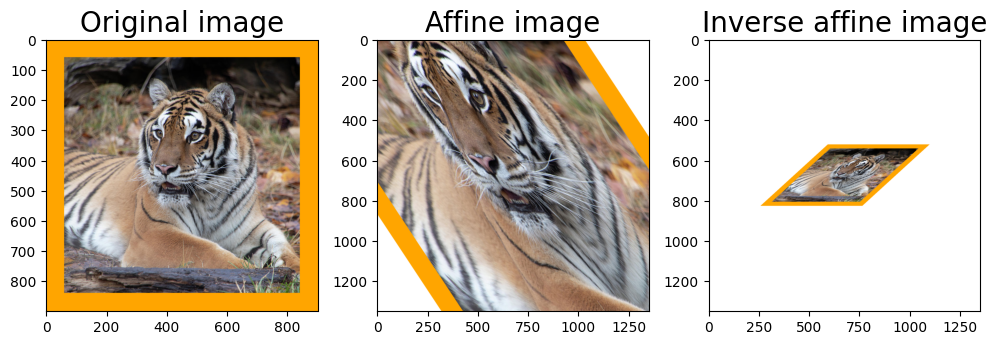

In [9]:
affine_matrix = np.array([
    [1 + factor/50., 0 + factor/20., 0],
    [0, 1 + factor/20., 0],
    [0, 0, 1]
])

# Зворотня матриця обчислюється через інверсію лінійної частини матриці, а потім ще заміщення
inverse_affine_matrix = np.array([
    [1/(1 + factor/50.), -(0 + factor/20.)/((1+factor/50.)*(1+factor/20.)), 0],
    [0, 1/(1 + factor/20.), 0],
    [0, 0, 1]
])

transformed_image = transform(transform_matrix=affine_matrix, factor=factor)
inverse_transformed_image = transform(transform_matrix=inverse_affine_matrix, factor=factor)

plt.figure(figsize=(10, 4))
plt.subplot(131), plt.imshow(image), plt.title('Original image', size=20)
plt.subplot(132), plt.imshow(transformed_image), plt.title('Affine image', size=20)
plt.subplot(133), plt.imshow(inverse_transformed_image), plt.title('Inverse affine image', size=20)
plt.tight_layout()
plt.show()

Homography

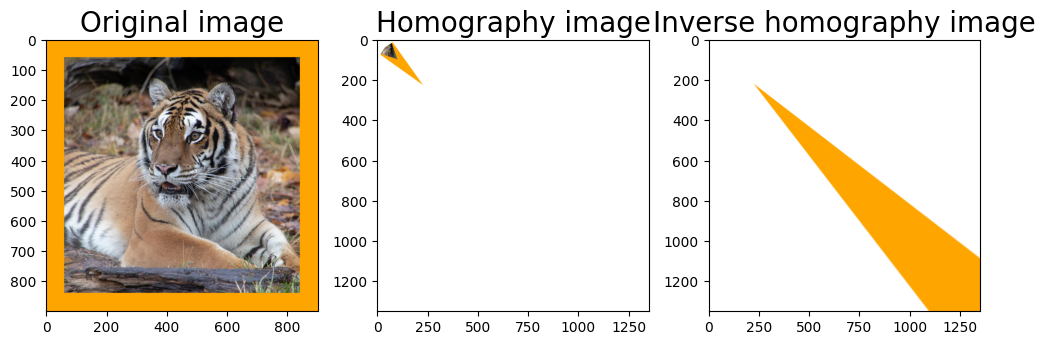

In [10]:
homography_matrix = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [factor**2/100000., factor**2/100000., 1]
])

# Зворотня матриця обчислюється як інверсія всієї матриці
inversed_homography_matrix = np.linalg.inv(homography_matrix)

transformed_image = transform(transform_matrix=homography_matrix, factor=factor)
inverse_transformed_image = transform(transform_matrix=inversed_homography_matrix, factor=factor)

plt.figure(figsize=(10, 4))
plt.subplot(131), plt.imshow(image), plt.title('Original image', size=20)
plt.subplot(132), plt.imshow(transformed_image), plt.title('Homography image', size=20)
plt.subplot(133), plt.imshow(inverse_transformed_image), plt.title('Inverse homography image', size=20)
plt.tight_layout()
plt.show()

Prove that geometric transformations
---


(a/ form groups) 
Щодо перетворень, кожне з них можна представити математично (власне у цій роботі це було продемонстровано).
Наскільки я розумію, то щоб бути групою потрібно задовільняти умови усіх аксіом: 
- замкненість (Closure) -- якщо A і B дві матриці перетворень (розглянутих в цій роботі), то їх добуток (A*B) буде також матрицею даних перетворень. З цього випливає замкненість.
- асоціативність (Associativity) -- тут візьмемо множення матриць, яке є асоціативним. Оскільки, якщо A, B, C - матриці перетворень, то (A * B ) * C = A * (B * C). З цього й випливає асоціативність.
- елемент ідентифікації (Identity Element) -- якщо застосувати одиничну матрицю до будь-якої матриці перетворення (A), результат буде таким же I * A = A * I = A. З цього випливає, що одинична матриця
є елементом ідентифікації для геометричним перетворень.
- зворотний елемент (Inverse Element) -- усі геометричні перетворення мають зворотню форму(обернені матриці). Відповідно з цього випливає, що існує зворотний елемент.

Геометричні перетворення утворюють групу, оскільки вони задовольняють усі чотири аксіоми.

(b/ these groups are nested) 
Тут потрібно довести вкладеність кожного виду геометричних перетворень в інший.

- Почнемо з найнижчого зсуви ("Translations") - фактично це частковий випадок "Euclidean" перетворення, де обертання рівне 0.
- Далі Евклідові перетворення ("Euclidean") - аналогічно попередньому, оскільки евклідові з масштабуванням дають перетворення "Similarity", а якщо коефіцієнт масштабування рівний 1, то це 
перетворення стає Евклідовим.
- Перетворення "Similarity" буде підгрупою "Affine" перетворень, якщо елементи головної діагоналі будуть рівні між собою, а також рівні кефу масштабування і a12 = -a21 = кефу масштабування 
множеному на синус.
- Афінні перетворення є частковим випадком перетворень "Homography", при a31 = a32 = 0 і a33 = 1.

Відповідні висновки:
- Перетворення "Translations" є підгрупою перетворень "Euclidean".
- Перетворення "Euclidean" є підгрупою перетворень "Similarity".
- Перетворення "Similarity" є підгрупою перетворень "Affine".
- Перетворення "Affine" є підгрупою перетворень "Homography".